# LAB01 - Detección de Phishing
### Sebastian Juarez - 21471

## Parte 1: Ingeniería de Características

### Exploración de datos

In [14]:
import pandas as pd

df = pd.read_csv('dataset_pishing.csv')
df.head()

,url,status
0,http://www.crestonwood.com/router.php,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,phishing
2,https://support-appleld.com.secureupdate.duila...,phishing
3,http://rgipt.ac.in,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,legitimate


In [15]:
status_counts = df['status'].value_counts()
status_counts

status
legitimate    5715
phishing      5715
Name: count, dtype: int64

## ¿Está balanceado el dataset?

Viendo como es que estan distribuidos los datos en la columna de status, podemos ver que los datos estan perfectamente balanceados. Esto se sabe solo viendo rapidamente al conteo de valores, ya que en legitimate y en phishing hay exactamente 5715 datos cada uno.

Si tuviera mas de uno que del otro, el modelo podria predecir mejor la parte con mayor datos.

### Derivacion de Características

1. ¿Qué ventajas tiene el análisis de una URL contra el análisis de otros datos, cómo el tiempo
de vida del dominio, o las características de la página Web?

El analisis que se centra especialmente en las URLs tiene ventajas notorias en la velocidad y la seguridad. Eso es ya que no se tiene que descargar el contenido del HTML, ofreciendo una deteccion en tiempo real. Usar esta metodologia ayuda a identificar ataques a los que se les llama "hora cero" o algunas paginas que no estan en las blacklists, y ademas opera a una alta velocidad al evitar la dependencia de servicios externos. Este enfoque puede ser independiente al idioma de la pagina y ha demostrado que es un buen acercamiento a paginas que tratan de ocultar su contenido.

2. ¿Qué características de una URL son más prometedoras para la detección de phishing?

Las caracteristicas mas prometedoras para detectar phishing son el largo de la URL y que es lo que pueden tener, ya que normalmente los atacantes usan direcciones muy largas para confundir a las personas y esconder el dominio real. Ademas, un factor que puede pasar desapercibido es la freciencia de caracteres como puntos, guiones, barras y arrobas, ya que si medimos la entropia de estos caracteres, se puede medir facilemente la sospecha de la direccion. Otros factores pueden ser el uso de direcciones IP en vez de dominios, numeros extraños de subdominios y algunas palaras clave como "login".

### Creacion de caracteristicas

In [ ]:
import re
import math
import ipaddress
from collections import Counter
from urllib.parse import urlparse

def normalize_url(url):
    url = str(url).strip()
    if not re.match(r'^https?://', url, flags=re.IGNORECASE):
        url = 'http://' + url
    return url

def get_parsed(url):
    return urlparse(normalize_url(url))

def get_hostname(url):
    return get_parsed(url).hostname or ''

def url_length(url):
    return len(str(url))

def hostname_length(url):
    return len(get_hostname(url))

def path_length(url):
    return len(get_parsed(url).path or '')

def count_dots(url):
    return str(url).count('.')

def count_hyphens(url):
    return str(url).count('-')

def digit_count(url):
    s = str(url)
    return sum(ch.isdigit() for ch in s)

def digit_ratio(url):
    s = str(url)
    return digit_count(s) / len(s) if s else 0.0

def has_ip_address(url):
    host = get_hostname(url)
    try:
        ipaddress.ip_address(host)
        return 1
    except ValueError:
        return 0

def subdomain_count(url):
    host = get_hostname(url).lower()
    if not host or has_ip_address(url):
        return 0
    parts = [p for p in host.split('.') if p]
    return max(len(parts) - 2, 0)

def has_at_symbol(url):
    return 1 if '@' in str(url) else 0

def shannon_entropy(text):
    s = str(text)
    if not s:
        return 0.0
    counts = Counter(s)
    n = len(s)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())

def shannon_entropy_nan(url):
    nan_chars = ''.join(ch for ch in str(url) if not ch.isalnum())
    return shannon_entropy(nan_chars)

LEGIT_CHAR_DISTRIBUTION = None

def build_char_distribution(urls, eps=1e-9):
    text = ''.join(str(u) for u in urls).lower()
    if not text:
        return {'a': 1.0}
    counts = Counter(text)
    vocab = set(counts.keys())
    total = sum(counts.values()) + eps * len(vocab)
    return {ch: (counts.get(ch, 0) + eps) / total for ch in vocab}

def relative_entropy(url):
    s = str(url).lower()
    if not s:
        return 0.0
    p_counts = Counter(s)
    n = len(s)
    p_dist = {ch: c / n for ch, c in p_counts.items()}

    q_dist = LEGIT_CHAR_DISTRIBUTION
    if not q_dist:
        q_dist = build_char_distribution([s])

    eps = 1e-12
    return sum(p * math.log2(p / (q_dist.get(ch, eps))) for ch, p in p_dist.items())

def count_sensitive_keywords(url):
    s = str(url).lower()
    keywords = ['login', 'secure', 'account', 'banking', 'verify', 'update', 'password', 'signin']
    return sum(s.count(k) for k in keywords)

def count_brand_keywords(url):
    parsed = get_parsed(url)
    host = (parsed.hostname or '').lower()
    path_query = ((parsed.path or '') + '?' + (parsed.query or '')).lower()
    brands = ['google', 'apple', 'paypal', 'microsoft', 'amazon', 'facebook', 'instagram', 'netflix']

    parts = [p for p in host.split('.') if p]
    if len(parts) >= 2:
        main_domain = '.'.join(parts[-2:])
        non_main = '.'.join(parts[:-2])
    else:
        main_domain = host
        non_main = ''

    count = 0
    for b in brands:
        if b in non_main:
            count += 1
        if b in path_query:
            count += 1
        if b in host and b not in main_domain:
            count += 1
    return count

def has_https_token_in_host(url):
    host = get_hostname(url).lower()
    return 1 if 'https' in host else 0

def count_slashes(url):
    return str(url).count('/')

def count_vowels_dom(url):
    host = get_hostname(url).lower()
    vowels = set('aeiou')
    return sum(ch in vowels for ch in host)

feature_functions = {
    'url_length': url_length,
    'hostname_length': hostname_length,
    'path_length': path_length,
    'count_dots': count_dots,
    'count_hyphens': count_hyphens,
    'digit_count': digit_count,
    'digit_ratio': digit_ratio,
    'has_ip_address': has_ip_address,
    'subdomain_count': subdomain_count,
    'has_at_symbol': has_at_symbol,
    'shannon_entropy_nan': shannon_entropy_nan,
    'relative_entropy': relative_entropy,
    'count_sensitive_keywords': count_sensitive_keywords,
    'count_brand_keywords': count_brand_keywords,
    'has_https_token_in_host': has_https_token_in_host,
    'count_slashes': count_slashes,
    'count_vowels_dom': count_vowels_dom
}

print('Funciones de caracteristicas definidas: ', len(feature_functions))

Funciones de caracteristicas definidas: 17


In [ ]:
LEGIT_CHAR_DISTRIBUTION = build_char_distribution(df.loc[df['status'] == 'legitimate', 'url'])

df_features = df.copy()
for feature_name, feature_func in feature_functions.items():
    df_features[feature_name] = df_features['url'].astype(str).apply(feature_func)

print('Df original:', df.shape)
print('Df con features:', df_features.shape)
print('Nuevas columnas agregadas:', len(feature_functions))
df_features.head()

Shape original: (11430, 2)
Shape con features: (11430, 19)
Nuevas columnas agregadas: 17


,url,status,url_length,hostname_length,path_length,count_dots,count_hyphens,digit_count,digit_ratio,has_ip_address,subdomain_count,has_at_symbol,shannon_entropy_nan,relative_entropy,count_sensitive_keywords,count_brand_keywords,has_https_token_in_host,count_slashes,count_vowels_dom
0,http://www.crestonwood.com/router.php,legitimate,37,19,11,3,0,0,0.000000,0,1,0,1.448816,0.544965,0,0,0,3,5
1,http://shadetreetechnology.com/V4/validation/a...,phishing,77,23,47,1,0,17,0.220779,0,0,0,1.148835,0.922729,0,0,0,5,8
2,https://support-appleld.com.secureupdate.duila...,phishing,126,50,20,4,1,19,0.150794,0,3,0,2.755058,0.853384,3,2,0,5,17
3,http://rgipt.ac.in,legitimate,18,11,0,2,0,0,0.000000,0,1,0,1.521928,0.938013,0,0,0,2,3
4,http://www.iracing.com/tracks/gateway-motorspo...,legitimate,55,15,33,2,2,0,0.000000,0,1,0,1.760964,0.392028,0,0,0,5,4


### Preprocesamiento

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

df_model = df_features.copy()
status_map = {
    'legitimate': 0,
    'legit': 0,
    'phishing': 1,
    'pishing': 1
}

df_model['status_bin'] = df_model['status'].astype(str).str.strip().str.lower().map(status_map)

if df_model['status_bin'].isna().any():
    unknown = sorted(df_model.loc[df_model['status_bin'].isna(), 'status'].astype(str).unique())

dropCols = [col for col in ['url', 'domain', 'dominio', 'status'] if col in df_model.columns]
df_model = df_model.drop(columns=dropCols)

print('Columnas eliminadas:', dropCols)
print('Shape despues de eliminar columnas:', df_model.shape)

Columnas eliminadas: ['url', 'status']
Shape despues de eliminar columnas: (11430, 18)


In [ ]:
X = df_model.drop(columns=['status_bin']).copy()
y = df_model['status_bin'].astype(int).copy()

X = X.apply(pd.to_numeric, errors='coerce')

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print('Shape X:', X.shape)
print('Shape X_scaled:', X_scaled.shape)
print('Distribucion y (0=legitimate, 1=phishing):')
print(y.value_counts())
X_scaled.head()

Shape X: (11430, 17)
Shape X_scaled: (11430, 17)
Distribucion y (0=legitimate, 1=phishing):
status_bin
0    5715
1    5715
Name: count, dtype: int64


,url_length,hostname_length,path_length,count_dots,count_hyphens,digit_count,digit_ratio,has_ip_address,subdomain_count,has_at_symbol,shannon_entropy_nan,relative_entropy,count_sensitive_keywords,count_brand_keywords,has_https_token_in_host,count_slashes,count_vowels_dom
0,-0.436245,-0.193964,-0.437905,0.379180,-0.477984,-0.334094,-0.594666,-0.092515,-0.041002,-0.148001,-0.608643,-0.328781,-0.321685,-0.246273,-0.03625,-0.685161,-0.346986
1,0.287212,0.177207,0.860007,-1.081073,-0.477984,0.707624,1.875919,-0.092515,-1.201046,-0.148001,-1.384896,0.664916,-0.321685,-0.246273,-0.03625,0.377443,0.525632
2,1.173447,2.682613,-0.113427,1.109307,0.001174,0.830179,1.092760,-0.092515,2.279084,-0.148001,2.771487,0.482507,4.289766,4.364530,-0.03625,0.377443,3.143483
3,-0.779888,-0.936306,-0.834489,-0.350946,-0.477984,-0.334094,-0.594666,-0.092515,-0.041002,-0.148001,-0.419452,0.705119,-0.321685,-0.246273,-0.03625,-1.216463,-0.928730
4,-0.110690,-0.565135,0.355263,-0.350946,0.480332,-0.334094,-0.594666,-0.092515,-0.041002,-0.148001,0.199095,-0.731076,-0.321685,-0.246273,-0.03625,0.377443,-0.637858


Hacemos este check para asegurarnos que se mantiene balanceado el dataset

### Seleccion de caracteristicas

In [ ]:
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

from sklearn.feature_selection import mutual_info_classif

dup_count = df_features.duplicated().sum()
print(f'Observaciones duplicadas en df_features: {dup_count}')
if dup_count > 0:
    df_features = df_features.drop_duplicates().reset_index(drop=True)
    print('Se eliminaron duplicados. Nuevo df:', df_features.shape)

X_fs = X.copy()
y_fs = y.copy()

constant_cols = X_fs.columns[X_fs.nunique(dropna=False) <= 1].tolist()

corr_with_target = X_fs.corrwith(y_fs).fillna(0.0)
abs_corr = corr_with_target.abs()
low_corr_cols = abs_corr[abs_corr < 0.01].index.tolist()

mi = mutual_info_classif(X_fs, y_fs, random_state=42)
mi_scores = pd.Series(mi, index=X_fs.columns).sort_values(ascending=False)
low_mi_cols = mi_scores[mi_scores < 0.001].index.tolist()

X_no_const = X_fs.drop(columns=constant_cols, errors='ignore')
corr_matrix = X_no_const.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

drop_cols = sorted(set(constant_cols + low_corr_cols + low_mi_cols + high_corr_drop))
selected_features = [c for c in X_fs.columns if c not in drop_cols]

X_selected = X_fs[selected_features].copy()

print('Columnas constantes:', constant_cols)
print('Columnas con baja correlacion con status (<0.01):', low_corr_cols)
print('Columnas con baja MI (<0.001):', low_mi_cols)
print('Columnas eliminadas por alta correlacion entre features (>0.95):', high_corr_drop)
print('Total columnas originales:', X_fs.shape[1])
print('Total columnas seleccionadas:', len(selected_features))
print('Features seleccionadas:', selected_features)

Observaciones duplicadas en df_features: 1
Se eliminaron duplicados. Nuevo shape: (11429, 19)
Columnas constantes: []
Columnas con baja correlacion con status (<0.01): []
Columnas con baja MI (<0.001): []
Columnas eliminadas por alta correlacion entre features (>0.95): []
Total columnas originales: 17
Total columnas seleccionadas: 17
Features seleccionadas: ['url_length', 'hostname_length', 'path_length', 'count_dots', 'count_hyphens', 'digit_count', 'digit_ratio', 'has_ip_address', 'subdomain_count', 'has_at_symbol', 'shannon_entropy_nan', 'relative_entropy', 'count_sensitive_keywords', 'count_brand_keywords', 'has_https_token_in_host', 'count_slashes', 'count_vowels_dom']


### Caracteristicas seleccionadas

#### En este caso se eligieron las caracteristicas mostradas anteriormente ya que gracias a los articulos que se nos compartieron, las notamos como las mas importantes para poder detectar el phishing. Estas toman las partes mas importantes del texto, como el uso de caracteres especiales, la longitud anormal o nombres de marcas, que se saben que pueden contener contenido malicioso. Ademas, se hizo un analisis de correlacion para poder eliminar las caracteristicas que no aportarian nada a la predicción.

## Parte 2 - Implementación

### Separacion de datos

### Separacion de datos

Se hizo una division teniendo 55% entrenamiento, 15% validacion y 30% prueba

In [ ]:
from sklearn.model_selection import train_test_split
from pathlib import Path

X_final = X_selected.copy()
y_final = y_fs.copy()

# Seccion de prueba - 30%
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_final, y_final, test_size=0.30, random_state=42, stratify=y_final
)

# 2) Seccion de validacion - 15% (lo restante a test - 55%)
val_ratio_over_train_val = 0.15 / 0.70
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_ratio_over_train_val, random_state=42, stratify=y_train_val
)

print('Shapes:')
print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

n_total = len(X_final)
print('Porcentajes reales:')
print('Train: ', (len(X_train)/n_total:.2%))
print('Val  :', (len(X_val)/n_total:.2%))
print('Test :', (len(X_test)/n_total:.2%))

train_df = X_train.copy()
train_df['status_bin'] = y_train

val_df = X_val.copy()
val_df['status_bin'] = y_val

test_df = X_test.copy()
test_df['status_bin'] = y_test

out_dir = Path('data_splits')
out_dir.mkdir(exist_ok=True)

train_path = out_dir / 'train_55.csv'
val_path = out_dir / 'val_15.csv'
test_path = out_dir / 'test_30.csv'

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print('Archivos guardados:')
print(train_path)
print(val_path)
print(test_path)

Shapes:
Train: (6286, 17) (6286,)
Val  : (1715, 17) (1715,)
Test : (3429, 17) (3429,)
Porcentajes reales:
Train: 55.00%
Val  : 15.00%
Test : 30.00%
Archivos guardados:
data_splits/train_55.csv
data_splits/val_15.csv
data_splits/test_30.csv


### Implementación

### Implementacion de modelos y evaluacion

En este caso se eligieron dos modelos de clasificacion, una regresion logistica y un random forest, ya que son modelos que se usan mucho para este tipo de tareas, y se sabe que pueden ser muy buenos para detectar patrones en los datos. Ademas, se pusieron metricas en validacion y prueba como la matriz de confusion, precision, recall, curva ROC y AUC.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

X_train_scaled = X_scaled.loc[X_train.index]
X_val_scaled = X_scaled.loc[X_val.index]
X_test_scaled = X_scaled.loc[X_test.index]

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
}

def evaluate_model(model_name, model, Xtr, ytr, Xv, yv, Xte, yte):
    model.fit(Xtr, ytr)

    metrics = {}
    for split_name, X_split, y_split in [
        ('validacion', Xv, yv),
        ('prueba', Xte, yte)
    ]:
        y_pred = model.predict(X_split)
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_split)[:, 1]
        else:
            y_score = model.decision_function(X_split)

        cm = confusion_matrix(y_split, y_pred)
        precision = precision_score(y_split, y_pred)
        recall = recall_score(y_split, y_pred)
        auc = roc_auc_score(y_split, y_score)
        fpr, tpr, _ = roc_curve(y_split, y_score)

        metrics[split_name] = {
            'cm': cm,
            'precision': precision,
            'recall': recall,
            'auc': auc,
            'fpr': fpr,
            'tpr': tpr
        }

    return metrics

results = {}

# Regresion logistica
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression',
    models['Logistic Regression'],
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    X_test_scaled, y_test
)

# Random Forest
results['Random Forest'] = evaluate_model(
    'Random Forest',
    models['Random Forest'],
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

summary_rows = []
for model_name, model_res in results.items():
    for split_name, vals in model_res.items():
        summary_rows.append({
            'modelo': model_name,
            'dataset': split_name,
            'precision': vals['precision'],
            'recall': vals['recall'],
            'auc': vals['auc']
        })

metrics_df = pd.DataFrame(summary_rows).sort_values(['modelo', 'dataset'])
display(metrics_df)

,modelo,dataset,precision,recall,auc
1,Logistic Regression,prueba,0.821705,0.742124,0.874024
0,Logistic Regression,validacion,0.824866,0.719114,0.875474
3,Random Forest,prueba,0.854988,0.859977,0.937468
2,Random Forest,validacion,0.864644,0.863636,0.937813


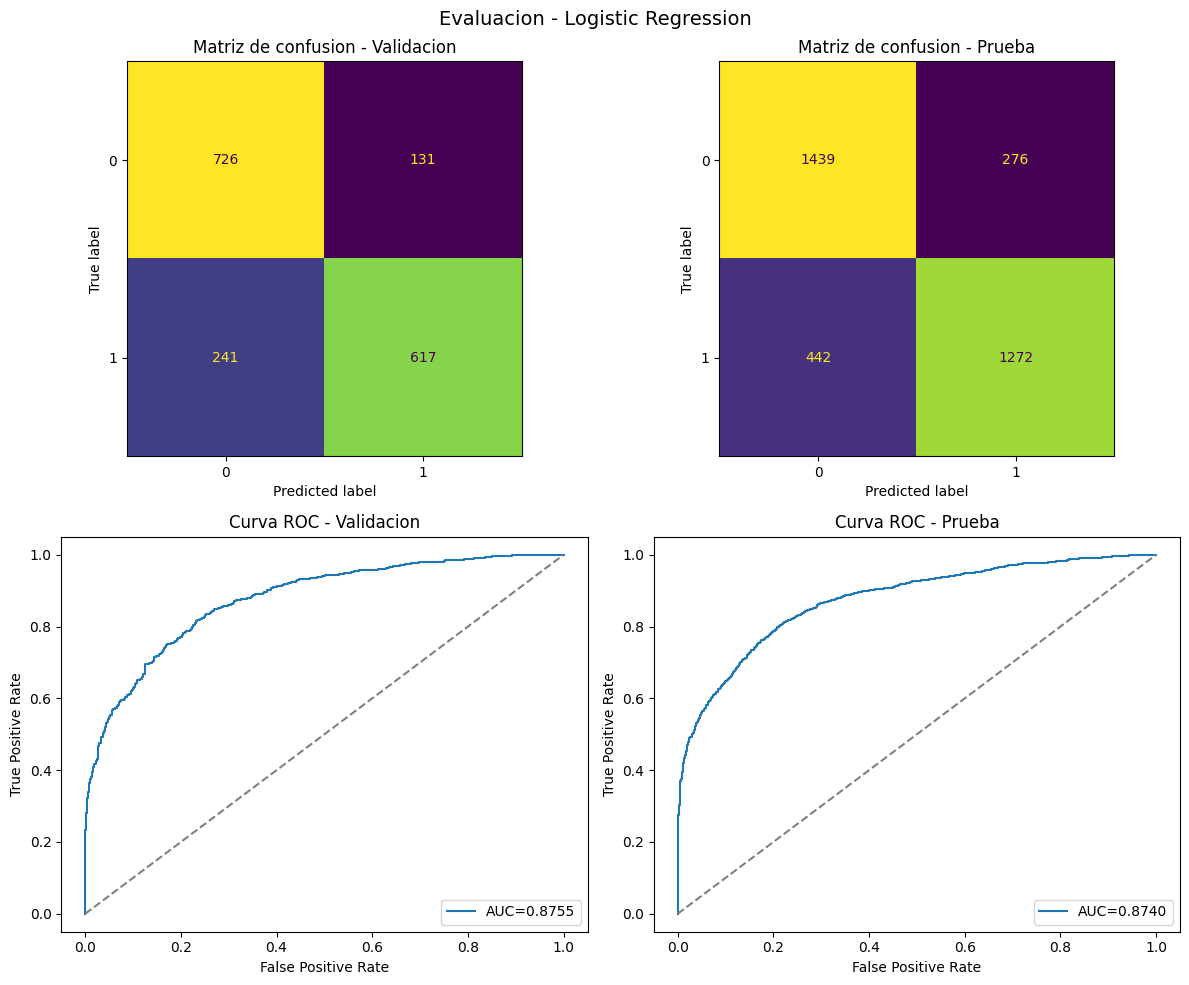

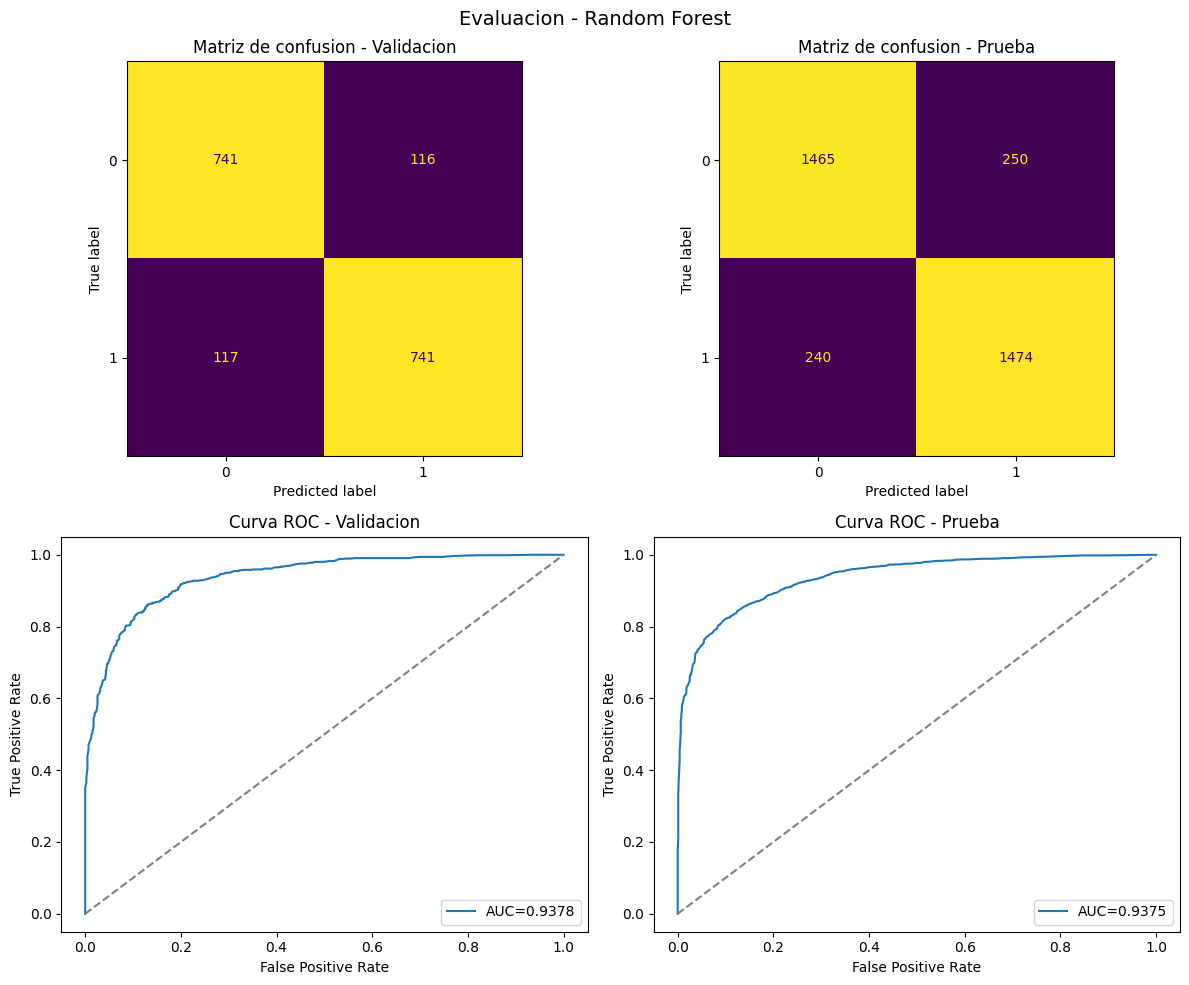

In [ ]:
for model_name, model_res in results.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Evaluacion - {model_name}', fontsize=14)

    # Matriz de confusion validacion
    ConfusionMatrixDisplay(model_res['validacion']['cm']).plot(ax=axes[0, 0], colorbar=False)
    axes[0, 0].set_title('Matriz de confusion - Validacion')

    # Matriz de confusion prueba
    ConfusionMatrixDisplay(model_res['prueba']['cm']).plot(ax=axes[0, 1], colorbar=False)
    axes[0, 1].set_title('Matriz de confusion - Prueba')

    # ROC validacion
    axes[1, 0].plot(model_res['validacion']['fpr'], model_res['validacion']['tpr'],
                    label=f"AUC={model_res['validacion']['auc']:.4f}")
    axes[1, 0].plot([0, 1], [0, 1], '--', color='gray')
    axes[1, 0].set_title('Curva ROC - Validacion')
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].legend(loc='lower right')

    # ROC prueba
    axes[1, 1].plot(model_res['prueba']['fpr'], model_res['prueba']['tpr'],
                    label=f"AUC={model_res['prueba']['auc']:.4f}")
    axes[1, 1].plot([0, 1], [0, 1], '--', color='gray')
    axes[1, 1].set_title('Curva ROC - Prueba')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

## Parte final - Discusión

4. ¿Cuál es el impacto de clasificar un sitio legítimo como phishing?

Si llegaramos a clasificar un sitio legítimo como phishing, el impacto seria que los usuarios no podrian entrar a estos lugares ya que se bloquean siendo estos inocentes. Esto genera una mala experiencia de usuario y ademas genera desconfianza en nosotros como el sistema de detección.

5. ¿Cuál es el impacto de clasificar un sitio de phishing como legítimo?

Si es que clasificamos un sitio de phishing como legítimo, el impacto seria que los usuarios podrian entrar a estos sitios y ser victimas de ataques de phishing, lo que puede llevar a perdida de información personal, financiera o incluso la suplantación de identidad. Este caso especialmente es uno que se tiene que evitar como se pueda, ya que este realmente puede dañar al usuario.

6. En base a las respuestas anteriores, ¿Qué métrica elegiría para comparar modelos similares de clasificación de phishing?

Yo eligiría principalmente el recall por que en este problema es peor dejar pasar un phishing que generar una falsa alarma. Como apoyo podria tambien tomar en cuenta AUC para ver el comportamiento del modelo, pero la principal seria el recall.

7. ¿Qué modelo funcionó mejor para la clasificación de phishing? ¿Por qué?

En este caso, el modelo que funciono mejor fue el random forest, ya que tiene una mejor precision, recall y AUC. Esto se lo podemos atribuir a que el random forest es un modelo que logra analizar mejor las relaciones entre las características, mientras que la regresion logistica es un modelo lineal que puede no ser capaz de capturar todas las complejidades de los datos. Además, el random forest es menos propenso a sobreajustar los datos, lo que puede ser una ventaja en este caso.

8. Una empresa desea utilizar su mejor modelo, debido a que sus empleados sufren constantes ataques de phishing mediante e-mail. La empresa estima que, de un total de 50,000 emails, un 15% son phishing. ¿Qué cantidad de alarmas generaría su modelo? ¿Cuántas positivas y cuantas negativas? ¿Funciona el modelo para el BR propuesto? En caso negativo, ¿qué propone para reducir la cantidad de falsas alarmas?

Tenemos 50,000 correos
El phishing real es de 15% -> 7,500 phishing reales y 42,500 legitimos
El recall del modelo es de 0.85 -> detecta 85% de los phishing reales -> 6,375 phishing detectados y 1,125 phishing no detectados
El FPR = 250/ (250 + 1465) = 0.146 -> 14.6% de los legitimos son falsos positivos -> 0.146 * 42,500 = 6,205 falsos positivos

Los verdaderos positivos son (0.859 * 7500) = 6442.5
Los falsos negativos son (7500 - 6442.5) = 1057.5
los falsos positivos son (0.1458 * 42500) = 6196.5
Los verdaderons negativos son (42500 - 6196.5) = 36303.5

Las alarmas positivas serian 6442.5 + 6196.5 = 12639
Las alarmas negativas serian 1057.5 + 36303.5 = 37361

Viendo esto, si detecta bastante phising pero tambien genera muchas falsas alarmas, lo que puede ser malo para el negocio. Para reducir esto, podriamos tratar de reducir el umbral, calibrar las probablidaes o agregar reglas especiales en el negocio y asi filtrar las alertas.
